In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Load the Iris dataset

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

# 2. Convert the dataset into a DataFrame for easier inspection

In [4]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = [target_names[i] for i in y]

# 3. Display the first five rows of the dataset

In [5]:
print("\n========== First Five Rows of the Dataset ==========")
print(df.head())


========== First Five Rows of the Dataset ==========
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


# 4. Count the number of samples in each class

In [6]:
print("\n========== Class Distribution ==========")
print(df["species"].value_counts())


========== Class Distribution ==========
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# 5. Split the dataset into training and testing sets
#    80% for training, 20% for testing

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Check the number of rows and columns
X_train has 120 rows and 4 columns
X_test has 30 rows and 4 columns
y_train has 120 labels
y_test has 30 labels

In [8]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)


# 6. Build and train the decision tree classifier
#    max_depth=3 limits the maximum depth of the tree
#    min_samples_leaf=5 requires each leaf node to contain at least 5 samples
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [9]:
clf = tree.DecisionTreeClassifier(
    criterion= 'gini',
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

# 7. Make predictions on the test set

In [10]:
y_pred = clf.predict(X_test)

# 8. Evaluate the model with a full classification report

In [11]:
print("\n========== Classification Report ==========")
print(classification_report(y_test, y_pred, target_names=target_names))


========== Classification Report ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# 9. Analyze feature importance

In [12]:
print("\n========== Feature Importance ==========")

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": clf.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance_df.to_string(index=False))



========== Feature Importance ==========
          feature  importance
petal length (cm)    0.925108
 petal width (cm)    0.074892
sepal length (cm)    0.000000
 sepal width (cm)    0.000000


# 10. Visualize the decision tree

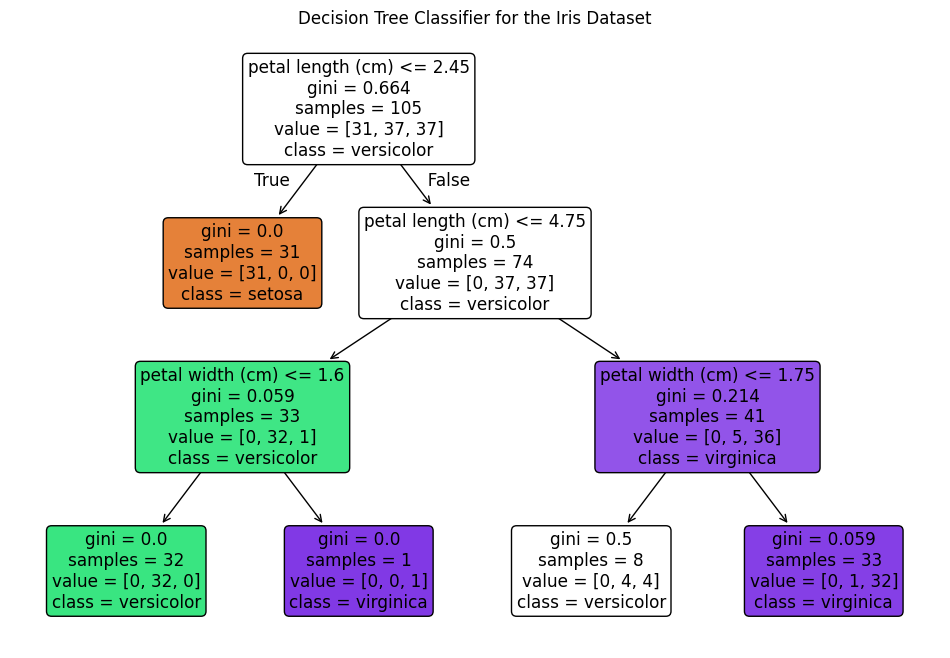

In [13]:
plt.figure(figsize=(12, 8))

tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier for the Iris Dataset")
plt.show()